In [63]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

import joblib

In [64]:
import imblearn
print(imblearn.__version__)

0.14.0


In [65]:
import pandas as pd

df = pd.read_csv(r"C:\Users\supra\Downloads\creditcard.csv")

In [66]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [67]:
print(df.shape)

(284807, 31)


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [69]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [70]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [71]:
print(df["Class"].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [72]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [74]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train, y_train
)

In [75]:
print(y_train_smote.value_counts())

Class
0    227451
1    227451
Name: count, dtype: int64


In [76]:
model = XGBClassifier(
    tree_method="hist",
    device="cuda",
    random_state=42
)

model.fit(X_train_smote, y_train_smote)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,'cuda'
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [77]:
from xgboost import XGBClassifier

model = XGBClassifier(
    tree_method="hist",
    device="cuda",
    random_state=42
)

In [78]:
model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,'cuda'
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [79]:
y_pred = model.predict(X_test)

In [80]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9992626663389628


In [81]:
print("Precision:", precision_score(y_test, y_pred))

Precision: 0.8255813953488372


In [82]:
print("Recall:", recall_score(y_test, y_pred))

Recall: 0.7244897959183674


In [83]:
print("F1 Score:", f1_score(y_test, y_pred))

F1 Score: 0.7717391304347826


In [84]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.72      0.77        98

    accuracy                           1.00     56962
   macro avg       0.91      0.86      0.89     56962
weighted avg       1.00      1.00      1.00     56962



In [85]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[56849    15]
 [   27    71]]


In [86]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance.head(10))

   Feature  Importance
10     V10    0.348989
14     V14    0.262687
19     V19    0.171578
1       V1    0.069702
12     V12    0.053114
5       V5    0.015956
9       V9    0.014775
28     V28    0.012112
11     V11    0.006966
26     V26    0.005931


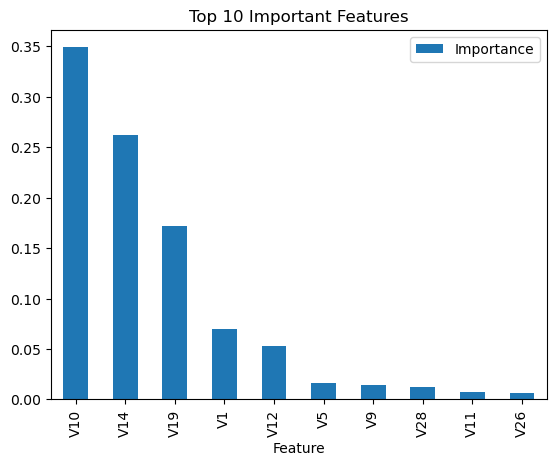

In [87]:
importance.head(10).plot(
    x="Feature",
    y="Importance",
    kind="bar"
)

plt.title("Top 10 Important Features")
plt.show()

In [88]:
joblib.dump(model, "credit_card_fraud_model.pkl")

['credit_card_fraud_model.pkl']

In [89]:
loaded_model = joblib.load("credit_card_fraud_model.pkl")

In [90]:
import os

print("Current sFolder:")
print(os.getcwd())



Current sFolder:
C:\Users\supra


In [91]:
import os

print(os.listdir())

['.anaconda', '.cache', '.conda', '.continuum', '.eclipse', '.frostwire5', '.ipynb_checkpoints', '.ipython', '.jupyter', '.kaggle', '.keras', '.matplotlib', '.p2', '.python_history', '.TurboVPN', '.virtual_documents', '.vscode', '.vscode-shared', 'anaconda3', 'ansel', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'Credit_Card_Fraud_Detection.ipynb', 'credit_card_fraud_model.pkl', 'CrossDevice', 'data', 'Documents', 'Downloads', 'eclipse', 'eclipse-workspace', 'Favorites', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'netshare.p12', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{25ad93ae-7a78-11f0-9fda-be04dbbea51c}.TM.blf', 'NTUSER.DAT{25ad93ae-7a78-11f0-9fda-be04dbbea51c}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{25ad93ae-7a78-11f0-9fda-be04dbbea51c}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'PrintHood', 'Recent', 'Saved Games', 'Searches', 'SEM2JAVA', 'SendTo', 'Start Menu', 'Templates', 'Untitle

In [92]:
import joblib

model = joblib.load(r"C:\Users\supra\credit_card_fraud_model.pkl")

In [93]:
import pandas as pd
from sklearn.model_selection import train_test_split


In [94]:
df = pd.read_csv(r"C:\Users\supra\Downloads\creditcard.csv")

In [95]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [97]:
y_pred = model.predict(X_test)

In [98]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9992626663389628
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.72      0.77        98

    accuracy                           1.00     56962
   macro avg       0.91      0.86      0.89     56962
weighted avg       1.00      1.00      1.00     56962

[[56849    15]
 [   27    71]]


In [99]:
model.set_params(device="cpu")
y_pred = model.predict(X_test)

In [100]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9066291717868914


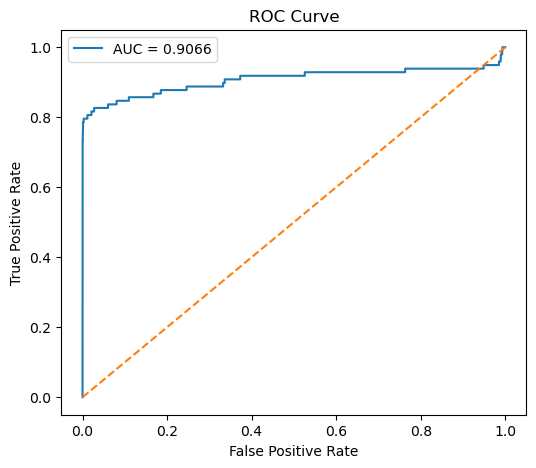

In [101]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

<Figure size 1000x800 with 0 Axes>

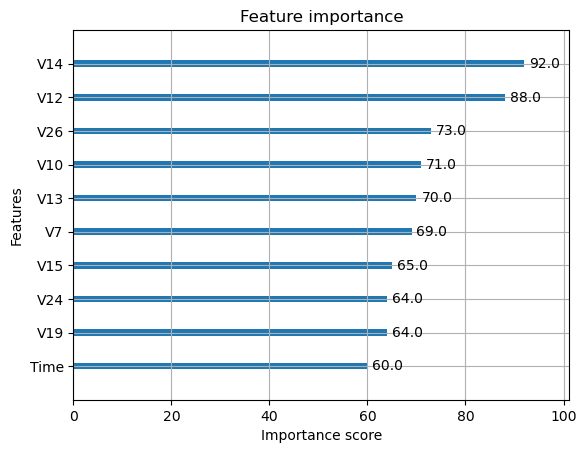

In [102]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plot_importance(model, max_num_features=10)
plt.show()

In [103]:
sample = X_test.iloc[[0]]

prediction = model.predict(sample)

print("Prediction:", prediction)
print("Actual:", y_test.iloc[0])

Prediction: [0]
Actual: 0


In [104]:
# Find one fraud transaction in the test set
fraud_sample = X_test[y_test == 1].iloc[[0]]

prediction = model.predict(fraud_sample)

print("Prediction:", prediction)
print("Actual:", 1)

Prediction: [1]
Actual: 1


In [105]:
import joblib

joblib.dump(model, "credit_card_fraud_model.pkl")

['credit_card_fraud_model.pkl']

In [106]:
import numpy as np
import pandas as pd

# Create one random transaction
new_data = pd.DataFrame({
    'Time': [45000],
    'V1': [-1.25],
    'V2': [0.85],
    'V3': [1.10],
    'V4': [-0.45],
    'V5': [0.30],
    'V6': [-0.20],
    'V7': [0.75],
    'V8': [-0.15],
    'V9': [0.40],
    'V10': [-0.35],
    'V11': [1.20],
    'V12': [-0.60],
    'V13': [0.50],
    'V14': [-0.90],
    'V15': [0.10],
    'V16': [0.25],
    'V17': [-0.15],
    'V18': [0.80],
    'V19': [-0.30],
    'V20': [0.05],
    'V21': [-0.10],
    'V22': [0.20],
    'V23': [0.15],
    'V24': [-0.40],
    'V25': [0.35],
    'V26': [0.12],
    'V27': [-0.08],
    'V28': [0.03],
    'Amount': [125.50]
})

print(new_data)

    Time    V1    V2   V3    V4   V5   V6    V7    V8   V9  ...   V20  V21  \
0  45000 -1.25  0.85  1.1 -0.45  0.3 -0.2  0.75 -0.15  0.4  ...  0.05 -0.1   

   V22   V23  V24   V25   V26   V27   V28  Amount  
0  0.2  0.15 -0.4  0.35  0.12 -0.08  0.03   125.5  

[1 rows x 30 columns]


In [107]:
prediction = loaded_model.predict(new_data)

print("Prediction:", prediction[0])

if prediction[0] == 0:
    print("✅ Normal Transaction")
else:
    print("🚨 Fraudulent Transaction")

Prediction: 0
✅ Normal Transaction


In [109]:
random_data = X_test.sample(10, random_state=42)

predictions = loaded_model.predict(random_data)

results = random_data.copy()
results["Prediction"] = predictions
results["Prediction"] = results["Prediction"].map({0: "Normal", 1: "Fraud"})

print(results)

            Time        V1        V2        V3        V4        V5        V6  \
2490      2061.0 -1.958955 -2.722373  0.065636 -2.051588  0.435947  4.509367   
90487    63041.0 -2.438283 -0.264593  2.889100  3.375535  1.729515 -0.650652   
156589  108462.0 -1.318108  1.179453 -1.120372  0.206072 -1.600136  0.452594   
138722   82811.0 -1.301314  1.216130  1.029738  1.292400 -0.062383  0.015550   
269869  163812.0  2.052545 -0.112153 -1.081547  0.416182 -0.177287 -1.146267   
267535  162813.0  2.045714 -0.763636 -2.028415 -0.507509  0.608281  0.664150   
222933  143183.0 -1.815309  1.915669 -3.376124  0.118831  2.611339 -1.213732   
281495  170214.0  2.020311  0.086688 -1.611067  0.348834  0.347278 -0.673398   
218751  141445.0 -0.772519  0.415909  1.298409 -0.943833  0.879942  1.621830   
29029    35285.0  1.136659  0.237730  0.453408  1.264912 -0.015730  0.154036   

              V7        V8        V9  ...       V21       V22       V23  \
2490    0.781314  0.993881 -0.800422  ...  0

In [110]:
random_data = X_test.sample(10, random_state=42)

predictions = loaded_model.predict(random_data)

results = random_data.copy()

results["Actual"] = y_test.loc[random_data.index].values
results["Predicted"] = predictions

results["Actual"] = results["Actual"].map({0: "Normal", 1: "Fraud"})
results["Predicted"] = results["Predicted"].map({0: "Normal", 1: "Fraud"})

print(results[["Actual", "Predicted"]])

        Actual Predicted
2490    Normal    Normal
90487   Normal    Normal
156589  Normal    Normal
138722  Normal    Normal
269869  Normal    Normal
267535  Normal    Normal
222933  Normal    Normal
281495  Normal    Normal
218751  Normal    Normal
29029   Normal    Normal


In [111]:
fraud_samples = X_test[y_test == 1].sample(5, random_state=42)

fraud_predictions = loaded_model.predict(fraud_samples)

results = fraud_samples.copy()
results["Actual"] = "Fraud"
results["Predicted"] = ["Fraud" if p == 1 else "Normal" for p in fraud_predictions]

print(results[["Actual", "Predicted"]])

       Actual Predicted
42528   Fraud     Fraud
149577  Fraud    Normal
119714  Fraud    Normal
152019  Fraud     Fraud
150663  Fraud     Fraud
